# Change in soil moisture across the PPE

In [1]:
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean.cm as cmo
from copy import deepcopy

import et_precip_ppe.plot as ppeplot
import et_precip_ppe.load as ppeload
import et_precip_ppe.analyze as ppealyz

In [2]:
# Get plotting settings
ppeplot.setup_plotting_workspace()

In [3]:
# Get area weights
cesm_weights = xr.open_dataset("/glade/work/bbuchovecky/PPE_analysis/weights/COUP_PPE_weights_atmgrid.nc").rename({"globweights": "globalweights"})
assert cesm_weights.landweights.sum(dim=["lat", "lon"]) == 1

# Identify variables to load
varlist = ["T_S", "RH_S", "q_S", "P", "ET", "TOTSOILLIQ", "SOILWATER_10CM"]

# Load time-mean variables
cesm_ppe, cesm_std = ppeload.get_cesm(varlist, "time_mean")
cesm_ts_ppe, cesm_ts_std = ppeload.get_cesm(varlist, "annual")

CESM2 time_mean:
  T_S
  RH_S
  q_S
  P
  ET
  TOTSOILLIQ
  SOILWATER_10CM
CESM2 annual:
  T_S
  RH_S
  q_S
  P
  ET
  TOTSOILLIQ
  SOILWATER_10CM


In [4]:
import scipy.stats as stats

In [5]:
def pearsonr_xr(da1, da2, dim=None):
    """
    Compute Pearson correlation between two xarray DataArrays.

    Parameters:
    - da1, da2: xarray DataArrays
    - dim: dimension(s) over which to compute correlation. If None, use 'member' if present,
           otherwise the first common dimension.

    Returns:
    - tuple of (corr, pvalue) as xarray DataArrays
    """
    # determine dimension(s) to correlate over
    if dim is None:
        common = [d for d in da1.dims if d in da2.dims]
        if 'member' in common:
            dim = ['member']
        else:
            dim = common[:1] if common else []
    if isinstance(dim, str):
        dim = [dim]
    core_dims = [d for d in dim if d in da1.dims and d in da2.dims]
    if not core_dims:
        raise ValueError('No common core dimension found to compute correlation')

    def _pearson(x, y):
        # x and y are 1D numpy arrays along the core dimension
        if x.size == 0 or y.size == 0:
            return np.nan, np.nan
        r, p = stats.pearsonr(x, y)
        return r, p

    corr, pval = xr.apply_ufunc(
        _pearson,
        da1, da2,
        input_core_dims=[core_dims, core_dims],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    return corr, pval


In [6]:
v = "SOILWATER_10CM"
sw_et_r, sw_et_p = pearsonr_xr(cesm_ppe[v] - cesm_std[v], cesm_ppe["ET"] - cesm_std["ET"])

v = "TOTSOILLIQ"
totsw_et_r, totsw_et_p = pearsonr_xr(cesm_ppe[v] - cesm_std[v], cesm_ppe["ET"] - cesm_std["ET"])

/glade/derecho/scratch/bbuchovecky/tmp/ipykernel_9289/3772379690.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x, y)


In [7]:
v = "T_S"
d_t_s = cesm_ppe[v] - cesm_std[v]
d_t_s_frac = (cesm_ppe[v] - cesm_std[v]) / cesm_std[v]

v = "SOILWATER_10CM"
d_sw = cesm_ppe[v] - cesm_std[v]
d_sw_frac = (cesm_ppe[v] - cesm_std[v]) / cesm_std[v]

v = "TOTSOILLIQ"
d_totsw = cesm_ppe[v] - cesm_std[v]
d_totsw_frac = (cesm_ppe[v] - cesm_std[v]) / cesm_std[v]

v = "q_S"
d_q_s = cesm_ppe[v] - cesm_std[v]

v = "RH_S"
d_rh_s = cesm_ppe[v] - cesm_std[v]

v = "ET"
d_et = cesm_ppe[v] - cesm_std[v]
d_et_frac = (cesm_ppe[v] - cesm_std[v]) / cesm_std[v]

v = "P"
d_p = cesm_ppe[v] - cesm_std[v]
d_p_frac = (cesm_ppe[v] - cesm_std[v]) / cesm_std[v]

d_p_e = (cesm_ppe["P"] - cesm_ppe["ET"]) - (cesm_std["P"] - cesm_std["ET"])

In [8]:
lat_slices = {
    "$[-60, -45]$": slice(-60, -45),
    "$[-45, -20]$": slice(-45, -20),
    "$[-20, 20]$": slice(-20, 20),
    "$[20, 45]$": slice(20, 45),
    "$[45, 60]$": slice(45, 60),
}
names = [
    # "T$_s$",
    "q$_s$",
    "RH$_s$",
    "ET",
    # "P",
    # "P$-$E",
]
variables = [
    # d_t_s,
    d_q_s,
    d_rh_s,
    d_et,
    # d_p,
    # d_p_e,
]
nvars = len(variables)

corr = np.zeros((nvars, nvars, 4, len(lat_slices.keys())))
for ilat, (label, lats) in enumerate(lat_slices.items()):
    corr_lat_names = np.empty((nvars, nvars), dtype='U16')
    for i in range(nvars):
        for j in range(nvars):
            x = variables[i].sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
            y = variables[j].sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
            lr = ppealyz.ols_single(x.sortby(x), y.sortby(x))
            pr = stats.pearsonr(x.sortby(x), y.sortby(x))
            result = np.array([pr.statistic, pr.pvalue, lr['slope'], lr['slope_ci_halfwidth']])
            corr[i, j, :, ilat] = result
            corr_lat_names[i, j] = names[i] + "~" + names[j]

/glade/u/home/bbuchovecky/projects/et_precip_ppe/src/et_precip_ppe/analyze.py:81: RuntimeWarning: divide by zero encountered in scalar divide
  t_stat = slope / slope_se
/glade/u/home/bbuchovecky/projects/et_precip_ppe/src/et_precip_ppe/analyze.py:81: RuntimeWarning: divide by zero encountered in scalar divide
  t_stat = slope / slope_se
/glade/u/home/bbuchovecky/projects/et_precip_ppe/src/et_precip_ppe/analyze.py:81: RuntimeWarning: divide by zero encountered in scalar divide
  t_stat = slope / slope_se
/glade/u/home/bbuchovecky/projects/et_precip_ppe/src/et_precip_ppe/analyze.py:81: RuntimeWarning: divide by zero encountered in scalar divide
  t_stat = slope / slope_se
/glade/u/home/bbuchovecky/projects/et_precip_ppe/src/et_precip_ppe/analyze.py:81: RuntimeWarning: divide by zero encountered in scalar divide
  t_stat = slope / slope_se
/glade/u/home/bbuchovecky/projects/et_precip_ppe/src/et_precip_ppe/analyze.py:81: RuntimeWarning: divide by zero encountered in scalar divide
  t_stat

In [9]:
corr_lat_names

array([['q$_s$~q$_s$', 'q$_s$~RH$_s$', 'q$_s$~ET'],
       ['RH$_s$~q$_s$', 'RH$_s$~RH$_s$', 'RH$_s$~ET'],
       ['ET~q$_s$', 'ET~RH$_s$', 'ET~ET']], dtype='<U16')

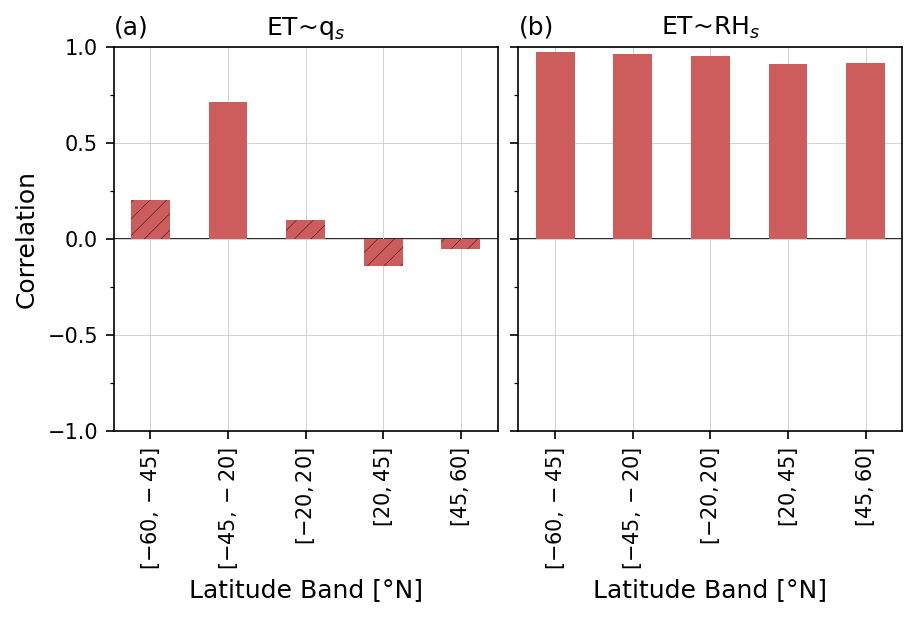

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(6, 4), sharey=True, sharex=True, layout='constrained')
axs = axes.ravel()

bar_w = 0.5
x = np.arange(5)
for i, ax in enumerate(axs):
    ax.tick_params(axis="both", labelsize=10)
    ax.axhline(0, lw=0.8, c='k', zorder=0)
    ax.set_ylim(-1, 1)
    ax.set_yticks([-1, -0.5, 0, 0.5, 1])
    ax.set_yticks([-0.75, -0.25, 0.25, 0.75], minor=True)

    r, p, slope, slope_ci = corr[2, i]

    ax.set_axisbelow(True)
    ax.set_xticks(x-bar_w/2)
    ax.grid(c='lightgray', lw=0.5, ls='-', zorder=100)

    bars_r = ax.bar(x - bar_w/2, r, width=bar_w, color='indianred', alpha=1, label='r')
    for patch, pval in zip(bars_r.patches, p):
        if pval >= 0.05:
            patch.set_hatch('///')

    ax.set_xticklabels(list(lat_slices.keys()), rotation=90)
    ax.set_xlabel("Latitude Band [\u00b0N]", fontsize=12)

axs[0].set_ylabel("Correlation", fontsize=12)

axs[0].set_title('(a)', loc='left', fontsize=12)
axs[0].set_title('ET~q$_s$', fontsize=12)

axs[1].set_title('(b)', loc='left', fontsize=12)
axs[1].set_title('ET~RH$_s$', fontsize=12)

fig.savefig('r2r_corr.pdf', bbox_inches='tight')

In [1]:
# stats_xpos = 0.025
# stats_ypos = 0.975
# stats_width = 0.46
# stats_height = 0.25

# fig, axs = plt.subplots(1, 2, figsize=(8, 4), layout='constrained', sharey=True)
# for ax in axs:
#     ax.tick_params(axis="both", labelsize=10)
#     ax.axvline(0, lw=0.8, c='k', zorder=0)
#     ax.axhline(0, lw=0.8, c='k', zorder=0)

# x = d_et.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
# y = d_q_s.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
# axs[0].scatter(x.sortby(x), y.sortby(x), c=ppeplot.c_dict['cesm'])
# lr = ppealyz.ols_single(x.sortby(x), y.sortby(x))
# pr = stats.pearsonr(x.sortby(x), y.sortby(x))
# axs[0].plot(
#     x.sortby(x), lr['intercept'] + lr['slope'] * x.sortby(x),
#     c=ppeplot.c_dict['cesm'],
# )
# axs[0].text(
#     stats_xpos, stats_ypos,
#     f"$m={lr['slope']: 0.3f} \\pm {lr['slope_ci_halfwidth']: 0.3f}$\n$r={pr.statistic: 0.2f}$\n$p={lr['slope_p_value']: 0.3f}$",
#     fontsize=12, color=ppeplot.c_dict['cesm'],
#     ha='left', va='top',
#     transform=axs[0].transAxes
# )

# x = d_t_s.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
# y = d_q_s.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
# axs[1].scatter(x, y, c=ppeplot.c_dict['cesm'])
# lr = ppealyz.ols_single(x.sortby(x), y.sortby(x))
# axs[1].plot(
#     x.sortby(x), lr['intercept'] + lr['slope'] * x.sortby(x),
#     c=ppeplot.c_dict['cesm'],
# )
# axs[1].text(
#     stats_xpos, stats_ypos,
#     f"$m={lr['slope']: 0.3f} \\pm {lr['slope_ci_halfwidth']: 0.3f}$\n$r={pr.statistic: 0.2f}$\n$p=${lr['slope_p_value']: 0.3e}",
#     fontsize=12, color=ppeplot.c_dict['cesm'],
#     ha='left', va='top',
#     transform=axs[1].transAxes
# )

# axs[0].set_ylabel("$\\Delta$q$_s$ [g kg$^{-1}$]", fontsize=12)
# axs[0].set_xlabel("$\\Delta$ET [mm day$^{-1}$]", fontsize=12)
# axs[1].set_xlabel("$\\Delta$T$_s$ [K]", fontsize=12)



In [2]:
# lats = slice(-90, 90)

# fig, axes = plt.subplots(3, 2, figsize=(8, 10), layout='constrained')
# axs = axes.ravel()
# for ax in axs:
#     ax.tick_params(axis="both", labelsize=10)
#     ax.axvline(0, lw=0.8, c='k', zorder=0)
#     ax.axhline(0, lw=0.8, c='k', zorder=0)

# stats_xpos = 0.025
# stats_ypos = 0.975

# ###### q_s

# x = d_et.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
# y = d_q_s.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
# axs[0].scatter(x.sortby(x), y.sortby(x), c=ppeplot.c_dict['cesm'])
# lr = ppealyz.ols_single(x.sortby(x), y.sortby(x))
# pr = stats.pearsonr(x.sortby(x), y.sortby(x))
# axs[0].plot(
#     x.sortby(x), lr['intercept'] + lr['slope'] * x.sortby(x),
#     c=ppeplot.c_dict['cesm'],
#     label=f"$m={lr['slope']: 0.3f} \\pm {lr['slope_ci_halfwidth']: 0.3f}$\n$r={pr.statistic: 0.2f}$\n$p=${lr['slope_p_value']: 0.3e}",
# )
# axs[0].legend(frameon=True, fancybox=False, labelcolor=ppeplot.c_dict['cesm'], fontsize=10)

# x = d_t_s.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
# y = d_q_s.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
# axs[1].scatter(x, y, c=ppeplot.c_dict['cesm'])
# lr = ppealyz.ols_single(x.sortby(x), y.sortby(x))
# pr = stats.pearsonr(x.sortby(x), y.sortby(x))
# axs[1].plot(
#     x.sortby(x), lr['intercept'] + lr['slope'] * x.sortby(x),
#     c=ppeplot.c_dict['cesm'],
#     label=f"$m={lr['slope']: 0.3f} \\pm {lr['slope_ci_halfwidth']: 0.3f}$\n$r={pr.statistic: 0.2f}$\n$p=${lr['slope_p_value']: 0.3e}",
# )
# axs[1].legend(frameon=True, fancybox=False, labelcolor=ppeplot.c_dict['cesm'], fontsize=10)


# ####### rh_s

# x = d_et.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
# y = d_rh_s.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
# axs[2].scatter(x.sortby(x), y.sortby(x), c=ppeplot.c_dict['cesm'])
# lr = ppealyz.ols_single(x.sortby(x), y.sortby(x))
# pr = stats.pearsonr(x.sortby(x), y.sortby(x))
# axs[2].plot(
#     x.sortby(x), lr['intercept'] + lr['slope'] * x.sortby(x),
#     c=ppeplot.c_dict['cesm'],
#     label=f"$m={lr['slope']: 0.3f} \\pm {lr['slope_ci_halfwidth']: 0.3f}$\n$r={pr.statistic: 0.2f}$\n$p=${lr['slope_p_value']: 0.3e}",
# )
# axs[2].legend(frameon=True, fancybox=False, labelcolor=ppeplot.c_dict['cesm'], fontsize=10)

# x = d_t_s.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
# y = d_rh_s.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
# axs[3].scatter(x, y, c=ppeplot.c_dict['cesm'])
# lr = ppealyz.ols_single(x.sortby(x), y.sortby(x))
# pr = stats.pearsonr(x.sortby(x), y.sortby(x))
# axs[3].plot(
#     x.sortby(x), lr['intercept'] + lr['slope'] * x.sortby(x),
#     c=ppeplot.c_dict['cesm'],
#     label=f"$m={lr['slope']: 0.3f} \\pm {lr['slope_ci_halfwidth']: 0.3f}$\n$r={pr.statistic: 0.2f}$\n$p=${lr['slope_p_value']: 0.3e}",
# )
# axs[3].legend(frameon=True, fancybox=False, labelcolor=ppeplot.c_dict['cesm'], fontsize=10)



# ######### P

# x = d_et.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
# y = d_p.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
# axs[4].scatter(x.sortby(x), y.sortby(x), c=ppeplot.c_dict['cesm'])
# lr = ppealyz.ols_single(x.sortby(x), y.sortby(x))
# pr = stats.pearsonr(x.sortby(x), y.sortby(x))
# axs[4].plot(
#     x.sortby(x), lr['intercept'] + lr['slope'] * x.sortby(x),
#     c=ppeplot.c_dict['cesm'],
#     label=f"$m={lr['slope']: 0.3f} \\pm {lr['slope_ci_halfwidth']: 0.3f}$\n$r={pr.statistic: 0.2f}$\n$p=${lr['slope_p_value']: 0.3e}",
# )
# axs[4].legend(frameon=True, fancybox=False, labelcolor=ppeplot.c_dict['cesm'], fontsize=10)

# x = d_t_s.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
# y = d_p.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
# axs[5].scatter(x, y, c=ppeplot.c_dict['cesm'])
# lr = ppealyz.ols_single(x.sortby(x), y.sortby(x))
# pr = stats.pearsonr(x.sortby(x), y.sortby(x))
# axs[5].plot(
#     x.sortby(x), lr['intercept'] + lr['slope'] * x.sortby(x),
#     c=ppeplot.c_dict['cesm'],
#     label=f"$m={lr['slope']: 0.3f} \\pm {lr['slope_ci_halfwidth']: 0.3f}$\n$r={pr.statistic: 0.2f}$\n$p=${lr['slope_p_value']: 0.3e}",
# )
# axs[5].legend(frameon=True, fancybox=False, labelcolor=ppeplot.c_dict['cesm'], fontsize=10)

# axs[0].set_ylabel("$\\Delta$q$_s$ [g kg$^{-1}$]", fontsize=12)
# axs[2].set_ylabel("$\\Delta$RH$_s$ [%]", fontsize=12)
# axs[4].set_ylabel("$\\Delta$P [mm day$^{-1}$]", fontsize=12)

# axs[1].set_yticklabels([])
# axs[3].set_yticklabels([])
# axs[5].set_yticklabels([])

# for ax in axs[:4]:
#     ax.set_xticklabels([])

# axs[4].set_xlabel("$\\Delta$ET [mm day$^{-1}$]", fontsize=12)
# axs[5].set_xlabel("$\\Delta$T$_s$ [K]", fontsize=12)

# fig.suptitle(f"{ppeplot.label_dict['cesm']} PPE", fontsize=14, fontweight='bold', x=0.55)
# fig.savefig("../scripts/figures/supp_scatter.pdf", bbox_inches="tight")

In [3]:
# lat_slices = {
#     "$[-60, -45]$": slice(-60, -45),
#     "$[-45, -20]$": slice(-45, -20),
#     "$[-20, 20]$": slice(-20, 20),
#     "$[20, 45]$": slice(20, 45),
#     "$[45, 60]$": slice(45, 60),
# }

# reln_labels = [
#     "q$_s$, E",
#     "q$_s$, T$_s$",
#     "q$_s$, P$-$E",
#     "RH$_s$, E",
#     "RH$_s$, T$_s$",
#     "RH$_s$, P$-$E",
#     "P, E",
#     "P, T$_s$",
#     "P, P$-$E",
# ]

# prs = []
# ps = []
# slopes = []
# slopes_ci = []
# for label, lats in lat_slices.items():
#     prs_lat = []
#     ps_lat = []
#     slopes_lat = []
#     slopes_ci_lat = []

#     ###### q_s

#     x = d_et.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#     y = d_q_s.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#     lr = ppealyz.ols_single(x.sortby(x), y.sortby(x))
#     pr = stats.pearsonr(x.sortby(x), y.sortby(x))
#     prs_lat.append(pr.statistic)
#     ps_lat.append(pr.pvalue)
#     slopes_lat.append(lr['slope'])
#     slopes_ci_lat.append(lr['slope_ci_halfwidth'])

#     x = d_t_s.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#     y = d_q_s.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#     lr = ppealyz.ols_single(x.sortby(x), y.sortby(x))
#     pr = stats.pearsonr(x.sortby(x), y.sortby(x))
#     prs_lat.append(pr.statistic)
#     ps_lat.append(pr.pvalue)
#     slopes_lat.append(lr['slope'])
#     slopes_ci_lat.append(lr['slope_ci_halfwidth'])

#     x = d_p_e.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#     y = d_q_s.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#     lr = ppealyz.ols_single(x.sortby(x), y.sortby(x))
#     pr = stats.pearsonr(x.sortby(x), y.sortby(x))
#     prs_lat.append(pr.statistic)
#     ps_lat.append(pr.pvalue)
#     slopes_lat.append(lr['slope'])
#     slopes_ci_lat.append(lr['slope_ci_halfwidth'])


#     ####### rh_s

#     x = d_et.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#     y = d_rh_s.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#     lr = ppealyz.ols_single(x.sortby(x), y.sortby(x))
#     pr = stats.pearsonr(x.sortby(x), y.sortby(x))
#     prs_lat.append(pr.statistic)
#     ps_lat.append(pr.pvalue)
#     slopes_lat.append(lr['slope'])
#     slopes_ci_lat.append(lr['slope_ci_halfwidth'])

#     x = d_t_s.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#     y = d_rh_s.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#     lr = ppealyz.ols_single(x.sortby(x), y.sortby(x))
#     pr = stats.pearsonr(x.sortby(x), y.sortby(x))
#     prs_lat.append(pr.statistic)
#     ps_lat.append(pr.pvalue)
#     slopes_lat.append(lr['slope'])
#     slopes_ci_lat.append(lr['slope_ci_halfwidth'])

#     x = d_p_e.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#     y = d_rh_s.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#     lr = ppealyz.ols_single(x.sortby(x), y.sortby(x))
#     pr = stats.pearsonr(x.sortby(x), y.sortby(x))
#     prs_lat.append(pr.statistic)
#     ps_lat.append(pr.pvalue)
#     slopes_lat.append(lr['slope'])
#     slopes_ci_lat.append(lr['slope_ci_halfwidth'])
    

#     ######### P

#     x = d_et.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#     y = d_p.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#     lr = ppealyz.ols_single(x.sortby(x), y.sortby(x))
#     pr = stats.pearsonr(x.sortby(x), y.sortby(x))
#     prs_lat.append(pr.statistic)
#     ps_lat.append(pr.pvalue)
#     slopes_lat.append(lr['slope'])
#     slopes_ci_lat.append(lr['slope_ci_halfwidth'])
    
#     x = d_t_s.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#     y = d_p.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#     lr = ppealyz.ols_single(x.sortby(x), y.sortby(x))
#     pr = stats.pearsonr(x.sortby(x), y.sortby(x))
#     prs_lat.append(pr.statistic)
#     ps_lat.append(pr.pvalue)
#     slopes_lat.append(lr['slope'])
#     slopes_ci_lat.append(lr['slope_ci_halfwidth'])

#     x = d_p_e.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#     y = d_p.sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#     lr = ppealyz.ols_single(x.sortby(x), y.sortby(x))
#     pr = stats.pearsonr(x.sortby(x), y.sortby(x))
#     prs_lat.append(pr.statistic)
#     ps_lat.append(pr.pvalue)
#     slopes_lat.append(lr['slope'])
#     slopes_ci_lat.append(lr['slope_ci_halfwidth'])
    


#     prs.append(deepcopy(prs_lat))
#     ps.append(deepcopy(ps_lat))
#     slopes.append(deepcopy(slopes_lat))
#     slopes_ci.append(deepcopy(slopes_ci_lat))


# prs = np.array(prs)
# ps = np.array(ps)
# slopes = np.array(slopes)
# slopes_ci = np.array(slopes_ci)

In [ ]:
# p_thresh = 0.05

# fig, axes = plt.subplots(3, 3, figsize=(10, 10), layout='constrained', sharex=True, sharey=True)
# axs = axes.ravel()    

# for i, reln in enumerate(reln_labels):
#     axs[i].tick_params(axis="both", labelsize=10)
#     axs[i].axhline(0, lw=0.8, c='k', zorder=0)
#     axs[i].set_ylim(-1, 1)
#     axs[i].set_yticks([-1, -0.5, 0, 0.5, 1])
#     axs[i].set_yticks([-0.75, -0.25, 0.25, 0.75], minor=True)
#     bars = axs[i].bar(
#         np.arange(5),
#         prs[:, i],
#         # slopes[:,i],
#         # yerr=slopes_ci[:,i],
#         capsize=3,
#         color=ppeplot.c_dict['cesm'],
#         alpha=0.8,
#     )
#     for patch, pval in zip(bars.patches, ps[:, i]):
#         if pval > p_thresh:
#             patch.set_hatch('///')
#     axs[i].set_title(f"corr({reln})", fontsize=12)

# for i in range(5):
#     for ax in axs[-3:]:
#         ax.set_xticks(np.arange(5))
#         ax.set_xticklabels(lat_slices.keys(), rotation=35, ha='right')
#         ax.set_xlabel("Latitude Band [\u00b0N]", fontsize=12)

# for i in range(3):
#     axes[i,0].set_ylabel("Correlation", fontsize=12)

# fig.suptitle(f"{ppeplot.label_dict['cesm']} PPE", fontsize=14, fontweight='bold', x=0.55)
# # fig.savefig("../scripts/figures/supp_latband_corr.pdf", bbox_inches="tight")

In [5]:
# lat_slices = {
#     "$[-60, -45]$": slice(-60, -45),
#     "$[-45, -20]$": slice(-45, -20),
#     "$[-20, 20]$": slice(-20, 20),
#     "$[20, 45]$": slice(20, 45),
#     "$[45, 60]$": slice(45, 60),
# }
# names = [
#     "T$_s$",
#     "q$_s$",
#     "RH$_s$",
#     "ET",
#     "P",
#     "P$-$E",
# ]
# variables = [
#     d_t_s,
#     d_q_s,
#     d_rh_s,
#     d_et,
#     d_p,
#     d_p_e,
# ]
# nvars = len(variables)

# corr = np.zeros((nvars, nvars, 4, len(lat_slices.keys())))
# for ilat, (label, lats) in enumerate(lat_slices.items()):
#     corr_lat_names = np.empty((nvars, nvars), dtype='U16')
#     for i in range(nvars):
#         for j in range(nvars):
#             x = variables[i].sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#             y = variables[j].sel(lat=lats).weighted(cesm_weights.landarea).mean(dim=['lat', 'lon'])
#             lr = ppealyz.ols_single(x.sortby(x), y.sortby(x))
#             pr = stats.pearsonr(x.sortby(x), y.sortby(x))
#             result = np.array([pr.statistic, pr.pvalue, lr['slope'], lr['slope_ci_halfwidth']])
#             corr[i, j, :, ilat] = result
#             corr_lat_names[i, j] = names[i] + "~" + names[j]

In [6]:
# p_thresh = 0.05

# fig, axes = plt.subplots(6, 6, figsize=(13, 13), layout='constrained', sharex=True, sharey=True)
# axs = axes.ravel()
# axs2 = []

# bar_w = 0.5
# x = np.arange(5)
# for i in range(nvars):
#     for j in range(nvars):
#         ax = axes[i, j]
#         # ax2 = ax.twinx()
#         # axs2.append(ax2)
#         # ax2.tick_params(axis="both", labelsize=10)
#         ax.tick_params(axis="both", labelsize=10)
#         ax.axhline(0, lw=0.8, c='k', zorder=0)
#         ax.set_ylim(-1, 1)
#         ax.set_yticks([-1, -0.5, 0, 0.5, 1])
#         ax.set_yticks([-0.75, -0.25, 0.25, 0.75], minor=True)

#         r, p, slope, slope_ci = corr[i, j]

#         # correlation bars on left axis
#         bars_r = ax.bar(x - bar_w/2, r, width=bar_w, color='indianred', alpha=0.8, label='r')

#         # # slopes on twin right axis (shared x positions)
#         # bars_s = ax2.bar(x + bar_w/2, slope, width=bar_w, yerr=slope_ci, capsize=3, color='lightseagreen', alpha=0.8, label='slope')

#         # apply hatching where p-values indicate insignificance (ps > p_thresh)
#         for patch, pval in zip(bars_r.patches, p):
#             if pval >= p_thresh:
#                 patch.set_hatch('///')
#         # for patch, pval in zip(bars_s.patches, p):
#         #     if pval >= p_thresh:
#         #         patch.set_hatch('///')
        
#         # compute symmetric y-limits for slopes axis so zero is centered
#         try:
#             max_abs = np.nanmax(np.abs(slope) + slope_ci)
#             if not np.isfinite(max_abs) or max_abs == 0:
#                 max_abs = np.nanmax(np.abs(slope) + slope_ci) if np.any(np.isfinite(slope)) else 1.0
#         except Exception:
#             max_abs = 1.0
#         pad = 1.1
#         # ax2.set_ylim(-max_abs * pad, max_abs * pad)

#         # label right axis for slopes
#         # ax2.tick_params(axis='y', labelcolor='lightseagreen')
#         ax.tick_params(axis='y', labelcolor='indianred')

#         if i == 0 and j == 0:
#             ax.legend(loc='upper left')
#             # ax2.legend(loc='upper right')
        
#         ax.set_title(corr_lat_names[i, j])
    
#         if j >= i:
#             ax.remove()
#             # ax2.remove()

# # set x ticks and labels on bottom row
# for ax in axs[-6:-1]:
#     ax.set_xticks(x)
#     ax.set_xticklabels(list(lat_slices.keys()), rotation=90, ha='right')
#     ax.set_xlabel("Latitude Band [\u00b0N]", fontsize=12)

# for i in range(6):
#     axes[i,0].set_ylabel("Correlation", fontsize=12, color='indianred')
   
# # for i in [5, 11, 17, 23]:
# #     axs2[i].set_ylabel('Sensitivity', color='lightseagreen', fontsize=12)

# fig.savefig("big_corr_plot.pdf")

In [7]:
# p_thresh = 0.05

# fig, axes = plt.subplots(3, 3, figsize=(12, 10), layout='constrained', sharex=True)
# axs = axes.ravel()
# axs2 = []

# alph = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i']

# bar_w = 0.35
# x = np.arange(5)
# for i, reln in enumerate(reln_labels):
#     ax = axs[i]
#     ax2 = ax.twinx()
#     axs2.append(ax2)
#     ax2.tick_params(axis="both", labelsize=10)
#     ax.tick_params(axis="both", labelsize=10)
#     ax.axhline(0, lw=0.8, c='k', zorder=0)
#     ax.set_ylim(-1, 1)
#     ax.set_yticks([-1, -0.5, 0, 0.5, 1])
#     ax.set_yticks([-0.75, -0.25, 0.25, 0.75], minor=True)

#     # correlation bars on left axis
#     bars_r = ax.bar(x - bar_w/2, prs[:, i], width=bar_w, color='indianred', alpha=0.8, label='r')

#     # slopes on twin right axis (shared x positions)
#     bars_s = ax2.bar(x + bar_w/2, slopes[:, i], width=bar_w, yerr=slopes_ci[:, i], capsize=3, color='lightseagreen', alpha=0.8, label='slope')

#     # apply hatching where p-values indicate insignificance (ps > p_thresh)
#     for patch, pval in zip(bars_r.patches, ps[:, i]):
#         if pval >= p_thresh:
#             patch.set_hatch('///')
#     for patch, pval in zip(bars_s.patches, ps[:, i]):
#         if pval >= p_thresh:
#             patch.set_hatch('///')

#     ax.set_title(f"({alph[i]}) {reln.replace(', ', ' and ')}", loc='left', fontsize=12)

#     # compute symmetric y-limits for slopes axis so zero is centered
#     try:
#         max_abs = np.nanmax(np.abs(slopes[:, i]) + slopes_ci[:, i])
#         if not np.isfinite(max_abs) or max_abs == 0:
#             max_abs = np.nanmax(np.abs(slopes[:, i])) if np.any(np.isfinite(slopes[:, i])) else 1.0
#     except Exception:
#         max_abs = 1.0
#     pad = 1.1
#     ax2.set_ylim(-max_abs * pad, max_abs * pad)

#     # label right axis for slopes
#     ax2.tick_params(axis='y', labelcolor='lightseagreen')
#     ax.tick_params(axis='y', labelcolor='indianred')

#     if i == 0:
#         ax.legend(loc='upper left')
#         ax2.legend(loc='upper right')

# # set x ticks and labels on bottom row
# for ax in axs[-3:]:
#     ax.set_xticks(x)
#     ax.set_xticklabels(list(lat_slices.keys()), rotation=45, ha='right')
#     ax.set_xlabel("Latitude Band [\u00b0N]", fontsize=12)

# for i in range(3):
#     axes[i,0].set_ylabel("Correlation", fontsize=12, color='indianred')
   
# for i in [2, 5, 8]:
#     axs2[i].set_ylabel('Slope', color='lightseagreen', fontsize=12)

# fig.suptitle(f"{ppeplot.label_dict['cesm']} PPE", fontsize=14, fontweight='bold', x=0.55)
# fig.savefig("../scripts/figures/supp_latband_corr_slopes.pdf", bbox_inches="tight")

In [8]:
# p_thresh = 0.05

# fig, axes = plt.subplots(3, 3, figsize=(12, 10), layout='constrained', sharex=True)
# axs = axes.ravel()
# axs2 = []

# alph = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i']

# bar_w = 0.35
# x = np.arange(5)
# for i, reln in enumerate(reln_labels):
#     ax = axs[i]
#     ax2 = ax.twinx()
#     axs2.append(ax2)
#     ax2.tick_params(axis="both", labelsize=10)
#     ax.tick_params(axis="both", labelsize=10)
#     ax.axhline(0, lw=0.8, c='k', zorder=0)
#     ax.set_ylim(-1, 1)
#     ax.set_yticks([-1, -0.5, 0, 0.5, 1])
#     ax.set_yticks([-0.75, -0.25, 0.25, 0.75], minor=True)

#     # correlation bars on left axis
#     bars_r = ax.bar(x - bar_w/2, prs[:, i], width=bar_w, color='indianred', alpha=0.8, label='r')

#     # slopes on twin right axis (shared x positions)
#     bars_s = ax2.bar(x + bar_w/2, slopes[:, i], width=bar_w, yerr=slopes_ci[:, i], capsize=3, color='lightseagreen', alpha=0.8, label='slope')

#     # apply hatching where p-values indicate significance (ps < p_thresh)
#     for patch, pval in zip(bars_r.patches, ps[:, i]):
#         if pval >= p_thresh:
#             patch.set_hatch('///')
#     for patch, pval in zip(bars_s.patches, ps[:, i]):
#         if pval >= p_thresh:
#             patch.set_hatch('///')

#     ax.set_title(f"({alph[i]}) {reln.replace(', ', ' and ')}", loc='left', fontsize=12)

#     # compute symmetric y-limits for slopes axis so zero is centered
#     try:
#         max_abs = np.nanmax(np.abs(slopes[:, i]) + slopes_ci[:, i])
#         if not np.isfinite(max_abs) or max_abs == 0:
#             max_abs = np.nanmax(np.abs(slopes[:, i])) if np.any(np.isfinite(slopes[:, i])) else 1.0
#     except Exception:
#         max_abs = 1.0
#     pad = 1.1
#     ax2.set_ylim(-max_abs * pad, max_abs * pad)

#     # label right axis for slopes
#     ax2.tick_params(axis='y', labelcolor='lightseagreen')
#     ax.tick_params(axis='y', labelcolor='indianred')

#     if i == 0:
#         ax.legend(loc='upper left')
#         ax2.legend(loc='upper right')

# # set x ticks and labels on bottom row
# for ax in axs[-3:]:
#     ax.set_xticks(x)
#     ax.set_xticklabels(list(lat_slices.keys()), rotation=45, ha='right')
#     ax.set_xlabel("Latitude Band [\u00b0N]", fontsize=12)

# for i in range(3):
#     axes[i,0].set_ylabel("Correlation", fontsize=12, color='indianred')
   
# for i in [2, 5, 8]:
#     axs2[i].set_ylabel('Slope', color='lightseagreen', fontsize=12)

# fig.suptitle(f"{ppeplot.label_dict['cesm']} PPE", fontsize=14, fontweight='bold', x=0.55)
# fig.savefig("../scripts/figures/supp_latband_corr_slopes.pdf", bbox_inches="tight")